In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("income_random_forest.csv")   

In [4]:
print(df.head())
print(df.info())

   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             120 non-null    int64
 1   EducationYears  120 non-null    int64
 2   HoursPerWeek    120 non-null    int64
 3   Experience      120 non-null    int64
 4   Income          120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB
None


In [6]:
X = df.drop("Income", axis=1)
y = df["Income"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=n,
    max_depth=3,  
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print(len(X_test))

Random Forest Accuracy: 1.0
24


In [15]:
tree_range = [10, 20, 50, 100, 150]
accuracies = []

for n in tree_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

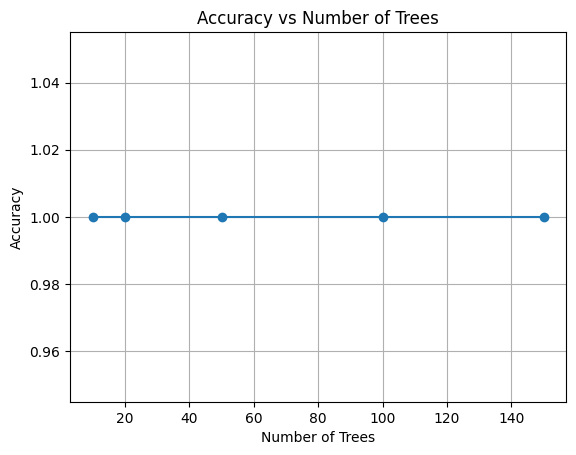

In [16]:
plt.figure()
plt.plot(tree_range, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.grid()
plt.show()

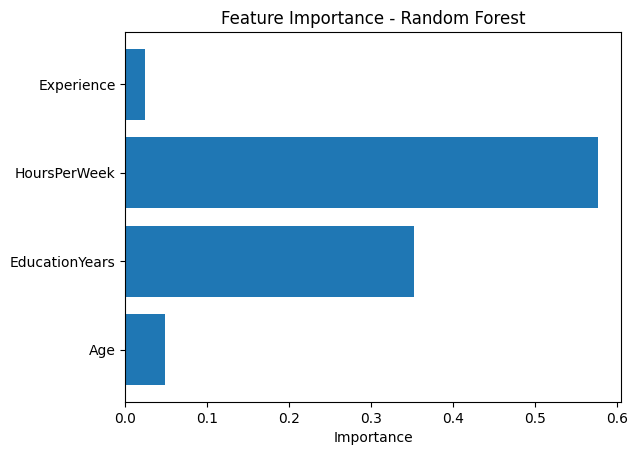

In [17]:
importances = rf_model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()